# HAT CHAIR Scores
This notebook tests CHAIR on the HAT data for Partial Abstention.

UPDATE 20260309: Tests on the 500 MS COCO Subset for the ECCV Supplement

In [1]:
import json
import os
import pickle
from chair import CHAIR
from tqdm.auto import tqdm

%load_ext autoreload
%autoreload 2

In [2]:
# global chair
coco_path = "coco_annotations"
cached_instance = "chair.pkl"
chair_evaluator = None
if os.path.exists(cached_instance):
    chair_evaluator = pickle.load(open(cached_instance, "rb"))
    print(f"loaded evaluator from cache: {cached_instance}")
else:
    print("cache not setted or not exist yet, building from scratch...")
    chair_evaluator = CHAIR(coco_path)
    pickle.dump(chair_evaluator, open(cached_instance, "wb"))
    print(f"cached evaluator to: {cached_instance}")

loaded evaluator from cache: chair.pkl


In [3]:
# load data
hat_file = "C:/Users/timot/Documents/UC Irvine/Research/Conformal Abstention/partial-abstainer/data/mscoco/mscoco-500-baselines_03-03-26.json"
with open(hat_file, "r", encoding="utf-8") as f:
    hat_data = json.load(f)

print(json.dumps(hat_data[0], indent=2))

{
  "file_name": "COCO_val2014_000000000139.jpg",
  "crowdworker_annotations": [
    "A woman stands in the dining area at the table.",
    "A room with chairs, a table, and a woman in it.",
    "A woman standing in a kitchen by a window",
    "A person standing at a table in a room.",
    "A living area with a television and a table"
  ],
  "image_url": "http://images.cocodataset.org/val2014/COCO_val2014_000000000139.jpg",
  "mscoco_objects": [
    "potted plant",
    "tv",
    "tv",
    "chair",
    "chair",
    "chair",
    "chair",
    "person",
    "person",
    "microwave",
    "refrigerator",
    "book",
    "book",
    "clock",
    "vase",
    "vase",
    "chair",
    "vase",
    "vase",
    "dining table"
  ],
  "captions": {
    "gpt": {
      "reference_caption": "Living room and kitchen area with wooden floors and yellow walls. A flat-screen television sits on a white and black TV stand against the left wall, beneath a wall-mounted cabinet. Four windows line the wall, letti

In [4]:
def image_id_from_filename(filename):
    """Gets the image id from the MS COCO filename.

    Args:
        filename (str): The MS COCO filename. Ex: COCO_val2014_000000016903.jpg

    Returns:
        str: The image id. Ex: 16903
    """
    return str(int(filename.split(".")[0].split("_")[-1]))


def compute_chair_overall(chair_scored_list):
    """
    Compute CHAIR metrics for a list of CHAIR scores.
    """
    # variables to hold
    num_caps = 0.0
    num_hallucinated_caps = 0.0
    hallucinated_word_count = 0.0
    coco_word_count = 0.0

    num_recall_gt_objects = 0.0
    num_gt_objects = 0.0

    for chair_output in chair_scored_list:
        num_caps += 1
        coco_word_count += len(chair_output["mscoco_generated_words"])
        num_hallucinated_caps += (
            1 if len(chair_output["mscoco_hallucinated_words"]) > 0 else 0
        )
        hallucinated_word_count += len(chair_output["mscoco_hallucinated_words"])
        num_gt_objects += len(chair_output["mscoco_gt_words"])
        num_recall_gt_objects += len(chair_output["recall_gt_objects"])

    # compute overall metrics
    chair_s = num_hallucinated_caps / num_caps
    chair_i = hallucinated_word_count / coco_word_count
    # add
    recall = num_recall_gt_objects / num_gt_objects if num_gt_objects > 0 else 0

    return {
        "CHAIRs": chair_s,
        "CHAIRi": chair_i,
        "Recall": recall,
    }

In [5]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\timot\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
# import copy

# vlms = ["llava", "blip", "minigpt", "lure2"]
vlms = [
    "gpt",
    "gemini",
    "llama",
    "molmo",
    "llava_hf",
    "llava_orig",
    "minigpt_llama",
    "minigpt_vicuna",
    "blip",
    "lure",
    "marine",
    "reverse",
    "fact_rlfh",
    "nullu_llava",
    "nullu_minigpt",
    "halc_llava",
    "halc_minigpt4",
]

# out_json = copy.deepcopy(hat_data)

# for i, image in enumerate(tqdm(hat_data)):
#     for vlm in vlms:
#         if vlm in image["captions"]:
#             # get the chair output for reference caption
#             atomics = [
#                 x["statement"] for x in image["captions"][vlm]["atomics"]["reference"]
#             ]
#             output = chair_evaluator.compute_chair(
#                 atomics,
#                 [image_id_from_filename(image["file_name"])] * len(atomics),
#                 compact_output=True,
#             )
#             for idx, chair_output in enumerate(output["sentences"]):
#                 chair_output.pop("image_id")
#                 chair_output.pop("caption")
#                 image["captions"][vlm]["atomics"]["reference"][idx]["chair"] = (
#                     chair_output
#                 )

In [10]:
"""
planned json layout
[
    {
        "captions" : {
            "vlm_model" : {
                "chair" : {chair metadata; scores found with the key "metrics"},
            }
        }
    }
]

planning code layout
1. grab all of the reference atomics
2. concat with space " ".join()
3. chair on the sentence
4. add it to the json

"""

vlms = [
    # 'gpt', 'gemini', 'llama', 'molmo',
    "llava_hf",
    "llava_orig",
    "minigpt_llama",
    "minigpt_vicuna",
    "blip",
    "lure",
    "marine",
    "reverse_t0.003",
    "reverse_t0.0003",
    "fact_rlhf",
    "nullu_llava",
    "nullu_minigpt",
    "halc_llava",
    "halc_minigpt4",
]

hat_data[0]["captions"][vlms[0]].keys()

dict_keys(['reference_caption', 'samples', 'atomics', 'atomic_similarity', 'chair'])

In [12]:
# get overall chair for each model
chair_saved = {vlm: {} for vlm in vlms}
print(f"{'{:<20}'.format('Model')}CHAIRs\t\tCHAIRi\t\tRecall")
for vlm in vlms:
    # concat all data from the hat data
    all_atoms = ["" for _ in range(len(hat_data))]
    all_image_ids = [0 for _ in range(len(hat_data))]
    for i, dat in enumerate(hat_data):
        # 1. grab atomics
        atomics = [
            atom["statement"] for atom in dat["captions"][vlm]["atomics"]["reference"]
        ]
        # 2. concat atomics
        atomics_str = " ".join(atomics)
        # 3. get iamge id
        image_id = int(image_id_from_filename(dat["file_name"]))

        # append
        all_atoms[i] = atomics_str
        all_image_ids[i] = image_id

    # compute CHAIR
    chair_out = chair_evaluator.compute_chair(
        all_atoms, all_image_ids, compact_output=True
    )

    print(
        f"{'{:<20}'.format(vlm)}{chair_out['overall_metrics']['CHAIRs']:.04f}\t\t{chair_out['overall_metrics']['CHAIRi']:.04f}\t\t{chair_out['overall_metrics']['Recall']:.04f}"
    )

    # save
    chair_saved[vlm] = chair_out

Model               CHAIRs		CHAIRi		Recall
llava_hf            0.3200		0.1045		0.6282
llava_orig          0.1660		0.0506		0.5670
minigpt_llama       0.4500		0.1304		0.5772
minigpt_vicuna      0.2440		0.0657		0.5969
blip                0.8160		0.3059		0.6696
lure                0.1760		0.0745		0.4605
marine              0.0840		0.0354		0.4866
reverse_t0.003      0.3720		0.0908		0.6837
reverse_t0.0003     0.1120		0.0355		0.4305
fact_rlhf           0.5960		0.1692		0.7309
nullu_llava         0.1640		0.0399		0.5880
nullu_minigpt       0.2960		0.0804		0.5695
halc_llava          0.1700		0.0447		0.6008
halc_minigpt4       0.2780		0.0802		0.5459


In [15]:
chair_out["sentences"]

[{'image_id': 139,
  'caption': 'There is a living room. The living room has a wooden floor. There is a large window. The window is on the left side of the room. There is a couch. The couch is in the center of the room. There is a coffee table. The coffee table is in front of the couch.',
  'mscoco_hallucinated_words': [('couch', 'couch'),
   ('couch', 'couch'),
   ('couch', 'couch')],
  'mscoco_gt_words': ['microwave',
   'chair',
   'person',
   'tv',
   'clock',
   'book',
   'vase',
   'dining table',
   'refrigerator',
   'potted plant'],
  'mscoco_generated_words': ['couch',
   'couch',
   'dining table',
   'dining table',
   'couch'],
  'hallucination_idxs': [34, 37, 60],
  'recall_gt_objects': ['dining table'],
  'metrics': {'CHAIRs': 1, 'CHAIRi': 0.6, 'Recall': 0.1}},
 {'image_id': 2255,
  'caption': 'There is an elephant. The elephant is wearing a collar. There is a tag on the collar. There is a jungle in the background. There are trees in the background. There are plants in

In [ ]:
# # save data
# with open(
#     "./data/hat-385_captioned_atomized_aloha-chair.json",
#     "w",
#     encoding='utf-8'
# ) as f:
#     json.dump(hat_data, f, indent=2, ensure_ascii=False)

# Baseline matching

In [77]:
import numpy as np
from tqdm.auto import tqdm

In [78]:
# ECCV Supplement stuff:
# making a table like Table 3
"""
Technique            VLM                Before          After       |       Threshold       Atomics

REVERSE
Nullu
HALC             LLaVA 1.5 7B
Fact-RLHF
MARINE      

LURE          MiniGPT-4 Vicuna 13B

Nullu         MiniGPT-4 Llama 2 7B
HALC
"""

# for each one, we need to
# 1. Compute original VLM CHAIR
# 2. Compute baseline CHAIR
# 3. Using the baseline CHAIR, simulate thresholding on data until CHAIR is met
# 4. Report the threshold and average atomics left (keep track of this)

print("")

## Compute CHAIR

In [169]:
# Step 1 and 2: Compute original or baseline CHAIR
def get_vlm_chair(vlm: str, chair_type: str = "CHAIRs"):
    """
    Computes the given CHAIR metric for the given VLM.

    Parameters
    ----------
    vlm : float
        The VLM on which to simulate thresholding.
    chair_type : str
        Default "CHAIRs". The specific CHAIR metric to look for (one of "CHAIRi", "CHAIRs", or "Recall").

    Returns
    -------
    chair_score : float
        The CHAIR score requested.
    """
    chair_vlm_dataset = dict()

    # collect atomics and image ids
    all_atomics = []
    all_image_ids = []
    empty_image_ids = []
    for dat in hat_data:
        # atomics
        atomics = [
            atom["statement"] for atom in dat["captions"][vlm]["atomics"]["reference"]
        ]
        all_atomics += atomics

        # image ids
        image_id = int(image_id_from_filename(dat["file_name"]))
        all_image_ids += [image_id for _ in atomics]

        # catch
        if len(atomics) == 0:
            empty_image_ids.append(image_id)

    # compute chair
    chair_out = chair_evaluator.compute_chair(
        all_atomics, all_image_ids, compact_output=True
    )

    return chair_out["overall_metrics"][chair_type]


get_vlm_chair("llava_orig")

0.040177528614809624

## Threshold Simulation

In [196]:
# Step 3: threshold simulation

# helper function: create dataset to compute CHAIR given the VLM
def _collect_vlm_chair_scores(vlm: str):
    """
    Helper function for simulate_thresholding(). Creates dataset with CHAIR scores for each atomic.

    Parameters
    ----------
    vlm : str
        The VLM for which we will compute CHAIR

    Returns
    -------
    chair_vlm_dataset : dict
        dataset with chair scores
    """
    # I'm just gonna brute force it
    chair_vlm_dataset = dict()

    # collect atomics and image ids
    all_atomics = []
    all_image_ids = []
    empty_image_ids = []
    for dat in hat_data:
        # atomics
        atomics = [
            atom["statement"] for atom in dat["captions"][vlm]["atomics"]["reference"]
        ]
        all_atomics += atomics

        # image ids
        image_id = int(image_id_from_filename(dat["file_name"]))
        all_image_ids += [image_id for _ in atomics]

        # catch
        if len(atomics) == 0:
            empty_image_ids.append(image_id)

    # compute chair
    chair_out = chair_evaluator.compute_chair(
        all_atomics, all_image_ids, compact_output=True
    )

    # parse output
    sentence_output = chair_out["sentences"]
    for out in sentence_output:
        # add new key if necessary
        image_key = out["image_id"]
        if image_key not in chair_vlm_dataset.keys():
            # print(f"{image_key} not found. Adding...")
            chair_vlm_dataset[image_key] = {}
            for chair_type in ["CHAIRi", "CHAIRs", "Recall"]:
                chair_vlm_dataset[image_key][chair_type] = []

        # append scores to list in the dict
        for chair_type in ["CHAIRi", "CHAIRs", "Recall"]:
            chair_vlm_dataset[image_key][chair_type] += [out["metrics"][chair_type]]

    # deal with empty atomic lists
    for image_key in empty_image_ids:
        chair_vlm_dataset[image_key] = {}
        for chair_type in ["CHAIRi", "CHAIRs", "Recall"]:
            chair_vlm_dataset[image_key][chair_type] = []

    # now it's all saved, so we should be ok to return
    # we could do additional parsing here or maybe later
    return chair_vlm_dataset


def _collect_vlm_atomic_similarity(vlm: str):
    """
    Helper function for simulate_thresholding(). Returns atomic similarity for the given VLM.
    """
    # ummmmm dict of lists?
    atomic_sim_scores = {}
    for dat in hat_data:
        image_id = int(image_id_from_filename(dat["file_name"]))

        # early quit
        if "atomic_similarity" not in dat["captions"][vlm].keys():
            continue
        curr_sim_scores = [
            atom_sim["avg_similarity_score"]
            for atom_sim in dat["captions"][vlm]["atomic_similarity"]
        ]
        atomic_sim_scores[image_id] = curr_sim_scores

    return atomic_sim_scores


def _get_simulated_scores(threshold, vlm, atomic_sim_scores, chair_type):
    """
    Helper function for simulate_thresholding(). Returns average CHAIR score based on parsed data and the average % atomics remaining.
    """
    # ok planning
    # go through each image in atomic_sim_scores via keys
    # threshold and remember indices where 1?
    # call CHAIR again idk

    # prep CHAIR input
    kept_atomics = []
    total_atomics = 0
    all_image_ids = []

    for dat in hat_data:
        img_id = int(image_id_from_filename(dat["file_name"]))
        curr_atom_sims = atomic_sim_scores[img_id]

        atomics = [
            atom["statement"] for atom in dat["captions"][vlm]["atomics"]["reference"]
        ]
        if len(curr_atom_sims) != len(atomics):
            # huh?
            # print(f"Atomic similarity count mismatch! {len(curr_atom_sims)} != {len(atomics)} - {img_id}")
            continue

        curr_kept = [
            atom for i, atom in enumerate(atomics) if curr_atom_sims[i] >= threshold
        ]

        # update CHAIR input
        kept_atomics += curr_kept
        all_image_ids += [img_id for _ in curr_kept]

        # update counter
        total_atomics += len(atomics)

    # compute chair
    chair_out = chair_evaluator.compute_chair(
        kept_atomics, all_image_ids, compact_output=True
    )

    return chair_out["overall_metrics"][chair_type], len(kept_atomics) / total_atomics


def _threshold_searching(
    thresholds, target_chair, atomic_sim_scores, vlm, chair_type, prev_n_thresholds=None
):
    """
    Helper function for simulate_thresholding(). Performs binary search on the list of thresholds so we don't search linearly. Returns the final threshold, avg chair, and pct atomics remaining.

    WE ARE ASSUMING CHAIR DECREASES MONOTONICALLY WITH THRESHOLD <- hm maybe a bad assumption lol i hope this doesnt break
    """
    n_thresholds = len(thresholds)

    # print(f"{n_thresholds} thresholds...")

    if n_thresholds == 1:
        # base case - we found it
        avg_chair, pct_remaining = _get_simulated_scores(
            thresholds[0], vlm, atomic_sim_scores, chair_type
        )
        return thresholds[0], avg_chair, pct_remaining
    if prev_n_thresholds == n_thresholds:
        # drop the biggest threshold? idk it should be close
        return _threshold_searching(
            thresholds[:-1],
            target_chair,
            atomic_sim_scores,
            vlm,
            chair_type,
            n_thresholds,
        )

    median_idx = int(n_thresholds / 2)
    test_threshold = thresholds[median_idx]

    # test
    avg_chair, _ = _get_simulated_scores(
        test_threshold, vlm, atomic_sim_scores, chair_type
    )

    # and check
    if avg_chair <= target_chair:
        # then a higher threshold will lead to a lower CHAIR
        # so we cut off everything higher than test_threshold
        return _threshold_searching(
            thresholds[: (median_idx + 1)],
            target_chair,
            atomic_sim_scores,
            vlm,
            chair_type,
            n_thresholds,
        )
    else:
        # then a lower threshold will lead to an even high CHAIR
        # this is not desired, so we cut off everything lower
        return _threshold_searching(
            thresholds[(median_idx + 1) :],
            target_chair,
            atomic_sim_scores,
            vlm,
            chair_type,
            n_thresholds,
        )


def simulate_thresholding(chair_score: float, vlm: str, chair_type: str = "CHAIRi"):
    """
    Simulates thresholding on the input vlm CHAIR scores to meet the threshold and get the % atomics remaining

    Parameters
    ----------
    chair_score : float
        The score for which to aim.
    vlm : str
        The VLM on which to simulate thresholding.
    chair_type : str
        Default `"CHAIRs"`. The specific CHAIR metric to look for (one of `"CHAIRi"`, `"CHAIRs"`, or `"Recall"`).

    Returns
    -------
    threshold : float
        The threshold at which the simulation on the VLM meets the given threshold for the given CHAIR score.
    pct_atomics : float
        The percent of remaining atomics
    """
    # value checking
    if chair_type.lower() not in ["chairi", "chairs", "recall"]:
        raise ValueError(
            f"""Parameter chair_type expected one of ["CHAIRi", "CHAIRs", "Recall"] but got {chair_type}."""
        )
    # correct the chair metric string
    corrections = {"chairi": "CHAIRi", "chairs": "CHAIRs", "recall": "Recall"}
    chair_type = corrections[chair_type.lower()]

    # look at the data from the saved dictionary
    chair_data = _collect_vlm_chair_scores(vlm)

    # parse & grab relevant CHAIR score
    parsed_chair_data = {}
    for dat in hat_data:
        image_id = int(image_id_from_filename(dat["file_name"]))
        parsed_chair_data[image_id] = chair_data[image_id][chair_type]

    # grab atomic similarity scores
    atomic_sim_scores = _collect_vlm_atomic_similarity(vlm)

    # ok uh try to simulate?
    # maybeeeeee sort the thresholds and go from there
    all_thresholds = []
    for sim_list in atomic_sim_scores.values():
        all_thresholds += sim_list
    all_thresholds = sorted(all_thresholds)

    # print(f"min threshold={all_thresholds[0]}")
    # move up the list
    thres, avg_chair, pct_remaining = _threshold_searching(
        all_thresholds, chair_score, atomic_sim_scores, vlm, chair_type
    )
    print(
        f"{vlm} {chair_type}: {avg_chair:.04f} <= {chair_score:.04f} at threshold {thres:.04f} (min threshold={all_thresholds[0]:.04f})"
    )
    # we want the matching threshold and pct remaining
    return thres, pct_remaining


simulate_thresholding(0.05858130258630259, "minigpt_vicuna", "CHAIRi")

minigpt_vicuna CHAIRi: 0.0584 <= 0.0586 at threshold 0.6494 (min threshold=0.0000)


(0.6494211733341217, 0.7545749704840614)

## Execution

In [197]:
# experimental setup
vlms = [
    # 'gpt', 'gemini', 'llama', 'molmo',
    "llava_hf",
    "llava_orig",
    "minigpt_llama",
    "minigpt_vicuna",
    "lure",
    "marine",
    "reverse_t0.003",
    "reverse_t0.0003",
    "fact_rlhf",
    "nullu_llava",
    "nullu_minigpt",
    "halc_llava",
    "halc_minigpt4",
]

base_vlms = [
    "llava_orig",
    "llava_hf",
    "minigpt_llama",
    "minigpt_vicuna",
]

baselines = {
    "lure": "minigpt_vicuna",
    "marine": "llava_hf",
    "reverse_t0.003": "llava_orig",
    "reverse_t0.0003": "llava_orig",
    "fact_rlhf": "llava_orig",
    "nullu_llava": "llava_orig",
    "nullu_minigpt": "minigpt_llama",
    "halc_llava": "llava_orig",
    "halc_minigpt4": "minigpt_llama",
}

chair_score_types = ["CHAIRi", "CHAIRs"]

chair_scores = {}
simulations = {}
# execute
for chair_type in tqdm(chair_score_types, desc="CHAIR Score Type", leave=True):
    chair_scores[chair_type] = {}
    simulations[chair_type] = {}

    out_str += f"{chair_type}\n"
    for vlm in tqdm(base_vlms, desc="Base VLM", leave=False):
        # base chair for comparison
        base_chair = get_vlm_chair(vlm, chair_type)
        chair_scores[chair_type][vlm] = base_chair

    # it should have gone through all 4 base VLMS
    for baseline_vlm in tqdm(list(baselines.keys()), desc="Baselines", leave=False):
        # base chair for comparison
        base_chair = get_vlm_chair(baseline_vlm, chair_type)
        chair_scores[chair_type][baseline_vlm] = base_chair

        base_vlm = baselines[baseline_vlm]

        # and run the simulation threshold
        matched_thres, pct_remaining = simulate_thresholding(
            base_chair, base_vlm, chair_type
        )
        simulations[chair_type][baseline_vlm] = [matched_thres, pct_remaining]

CHAIR Score Type:   0%|          | 0/2 [00:00<?, ?it/s]

Base VLM:   0%|          | 0/4 [00:00<?, ?it/s]

Baselines:   0%|          | 0/9 [00:00<?, ?it/s]

minigpt_vicuna CHAIRi: 0.0657 <= 0.0745 at threshold 0.0000 (min threshold=0.0000)
llava_hf CHAIRi: 0.0365 <= 0.0358 at threshold 0.8285 (min threshold=0.4366)
llava_orig CHAIRi: 0.0508 <= 0.0908 at threshold 0.4032 (min threshold=0.4032)
llava_orig CHAIRi: 0.0358 <= 0.0355 at threshold 0.6468 (min threshold=0.4032)
llava_orig CHAIRi: 0.0508 <= 0.1692 at threshold 0.4032 (min threshold=0.4032)
llava_orig CHAIRi: 0.0400 <= 0.0399 at threshold 0.6222 (min threshold=0.4032)
minigpt_llama CHAIRi: 0.0801 <= 0.0804 at threshold 0.7199 (min threshold=0.4390)
llava_orig CHAIRi: 0.0446 <= 0.0447 at threshold 0.5879 (min threshold=0.4032)
minigpt_llama CHAIRi: 0.0801 <= 0.0802 at threshold 0.7199 (min threshold=0.4390)


Base VLM:   0%|          | 0/4 [00:00<?, ?it/s]

Baselines:   0%|          | 0/9 [00:00<?, ?it/s]

minigpt_vicuna CHAIRs: 0.0418 <= 0.0478 at threshold 0.0000 (min threshold=0.0000)
llava_hf CHAIRs: 0.0278 <= 0.0285 at threshold 0.8484 (min threshold=0.4366)
llava_orig CHAIRs: 0.0402 <= 0.0743 at threshold 0.4032 (min threshold=0.4032)
llava_orig CHAIRs: 0.0284 <= 0.0283 at threshold 0.6665 (min threshold=0.4032)
llava_orig CHAIRs: 0.0402 <= 0.1476 at threshold 0.4032 (min threshold=0.4032)
llava_orig CHAIRs: 0.0343 <= 0.0345 at threshold 0.6072 (min threshold=0.4032)
minigpt_llama CHAIRs: 0.0590 <= 0.0589 at threshold 0.6997 (min threshold=0.4390)
llava_orig CHAIRs: 0.0393 <= 0.0392 at threshold 0.5478 (min threshold=0.4032)
minigpt_llama CHAIRs: 0.0531 <= 0.0533 at threshold 0.7211 (min threshold=0.4390)


In [191]:
# save the pickle
import pickle

# ok actually it only takes 2.5 minutes and not the 3 hours I expected
with open("chair_scores.pkl", "wb") as f:
    pickle.dump(chair_scores, f)

with open("chair_simulations.pkl", "wb") as f:
    pickle.dump(simulations, f)

## Output formatting

In [192]:
import pyperclip

"""
Ok let's think about this

We have
chair_scores = {
    chair_type : {
        VLM : base chair score for that VLM
    }
}

and

simulations = {
    chair_type : {
        baseline : [matched_thres, pct_remaining]
    }
}

Copying the diagram from earlier,
Technique            VLM                Before          After       |       Threshold       Atomics

REVERSE
Nullu
HALC             LLaVA 1.5 7B
Fact-RLHF
MARINE      

LURE          MiniGPT-4 Vicuna 13B

Nullu         MiniGPT-4 Llama 2 7B
HALC

We care about Technique (baseline), VLM (base), Before (chair_scores), After (chair_scores), Threshold (simulations), and Atomics (simulations)
So let's just print everything
"""

out_str = ""
for chair_type in chair_score_types:
    out_str += f"{chair_type}\n"
    out_str += "Technique\tVLM\tBefore\tAfter\tThreshold\tAtomics\n"
    # print(chair_type)
    # print("Technique\tVLM\tBefore\tAfter\tThreshold\tAtomics")

    for technique in list(baselines.keys()):
        # get corresponding baseline
        base_vlm = baselines[technique]
        before = chair_scores[chair_type][base_vlm]
        after = chair_scores[chair_type][technique]
        threshold, pct_remaining = simulations[chair_type][technique]

        # change pct remaining formatting
        pct_remaining = pct_remaining * 100

        # print
        # print(f"{technique}\t{base_vlm}\t{before:.04f}\t{after:.04f}\t{threshold:.04f}\t{pct_remaining:.02f}")
        out_str += f"{technique}\t{base_vlm}\t{before:.04f}\t{after:.04f}\t{threshold:.04f}\t{pct_remaining:.02f}\n"

    # add a space between outputs
    out_str += f"\n"

print(out_str)
pyperclip.copy(out_str)

CHAIRi
Technique	VLM	Before	After	Threshold	Atomics
lure	minigpt_vicuna	0.0657	0.0745	0.0000	100.00
marine	llava_hf	0.1048	0.0358	0.8079	22.89
reverse_t0.003	llava_orig	0.0508	0.0908	0.4032	100.00
reverse_t0.0003	llava_orig	0.0508	0.0355	0.7422	50.92
fact_rlhf	llava_orig	0.0508	0.1692	0.4032	100.00
nullu_llava	llava_orig	0.0508	0.0399	0.7315	53.14
nullu_minigpt	minigpt_llama	0.1304	0.0804	0.4390	100.00
halc_llava	llava_orig	0.0508	0.0447	0.7212	55.72
halc_minigpt4	minigpt_llama	0.1304	0.0802	0.4390	100.00

CHAIRs
Technique	VLM	Before	After	Threshold	Atomics
lure	minigpt_vicuna	0.0418	0.0478	0.0000	100.00
marine	llava_hf	0.0894	0.0285	0.9705	3.30
reverse_t0.003	llava_orig	0.0402	0.0743	0.4032	100.00
reverse_t0.0003	llava_orig	0.0402	0.0283	0.7315	53.14
fact_rlhf	llava_orig	0.0402	0.1476	0.4032	100.00
nullu_llava	llava_orig	0.0402	0.0345	0.7212	55.72
nullu_minigpt	minigpt_llama	0.0803	0.0589	0.4390	100.00
halc_llava	llava_orig	0.0402	0.0392	0.6955	64.58
halc_minigpt4	minigpt_llama	0.0803

## Plots

In [194]:
# ok idk what's happening so I'm gonna plot the CHAIRi scores
import matplotlib.pyplot as plt

base_vlms = [
    "llava_orig",
    "llava_hf",
    "minigpt_llama",
    "minigpt_vicuna",
]
chair_score_types = ["CHAIRi", "CHAIRs"]

# save the data
plotting_data = {}

for vlm in tqdm(base_vlms, desc="VLM"):
    plotting_data[vlm] = {}

    # look at the data from the saved dictionary
    chair_data = _collect_vlm_chair_scores(vlm)

    for chair_type in tqdm(chair_score_types, desc="CHAIR Type"):
        plotting_data[vlm][chair_type] = {}
        # parse & grab relevant CHAIR score
        parsed_chair_data = {}
        for dat in hat_data:
            image_id = int(image_id_from_filename(dat["file_name"]))
            parsed_chair_data[image_id] = chair_data[image_id][chair_type]

        # grab atomic similarity scores
        atomic_sim_scores = _collect_vlm_atomic_similarity(vlm)

        # ok uh try to simulate?
        # maybeeeeee sort the thresholds and go from there
        all_thresholds = []
        for sim_list in atomic_sim_scores.values():
            all_thresholds += sim_list
        all_thresholds = sorted(all_thresholds)

        all_avg_chairs = []
        all_pcts_remaining = []
        # move up the list
        for thres in tqdm(all_thresholds, desc="Thresholding...", leave=False):
            avg_chair, pct_remaining = _get_simulated_scores(
                thres, vlm, atomic_sim_scores, chair_type
            )

            all_avg_chairs.append(avg_chair)
            all_pcts_remaining.append(pct_remaining)

        # save the data
        plotting_data[vlm][chair_type]["thresholds"] = all_thresholds
        plotting_data[vlm][chair_type]["pcts_remaining"] = all_pcts_remaining
        plotting_data[vlm][chair_type]["chair_scores"] = all_avg_chairs

# save in pickle
with open("chair_plotting_data.pkl", "wb") as f:
    pickle.dump(plotting_data, f)

VLM:   0%|          | 0/4 [00:00<?, ?it/s]

CHAIR Type:   0%|          | 0/2 [00:00<?, ?it/s]

Thresholding...:   0%|          | 0/4281 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Plotting constants
colors = [
    # "#000000",  # black
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    # "#F0E442",  # yellow
    # "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

VLM_RENAMED = {
    "gpt": "GPT 4.1",
    "gemini": "Gemini 2.5 Flash",
    "llama": "Llama 3.2 90B",
    "molmo": "Molmo 72B",
    "llava_hf": "LLaVA 1.5 7B (HF)",
    "llava_orig": "LLaVA 1.5 7B (Orig)",
    "minigpt_llama": "MiniGPT-4 (Llama 2 7B)",
    "minigpt_vicuna": "MiniGPT-4 (Vicuna 13B)",
    "blip": "InstructBLIP 13B",
}

plot_scale = 7

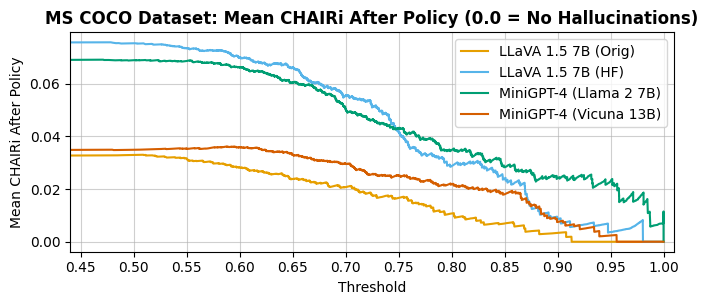

In [ ]:
"""
CHAIRi
"""
chair_type = "CHAIRi"
fig, ax = plt.subplots(1, 1, figsize=(plot_scale, plot_scale * 0.45))

for vlm_i, vlm in enumerate(base_vlms):
    # open up the data
    all_thresholds = plotting_data[vlm][chair_type]["thresholds"]
    pct_remaining = plotting_data[vlm][chair_type]["pcts_remaining"]
    chair_scores = plotting_data[vlm][chair_type]["chair_scores"]

    ax.plot(all_thresholds, chair_scores, label=VLM_RENAMED[vlm], color=colors[vlm_i])

ax.set_ylabel(f"Mean {chair_type} After Policy")
ax.set_xlabel("Threshold")
ax.set_xticks([round(t, 2) for t in np.arange(0, 1.01, 0.05)])

ax.set_title(
    f"MS COCO Dataset: Mean {chair_type} After Policy (0.0 = No Hallucinations)",
    fontweight="bold",
)

# TODO
# ax.set_ylim
# ax.set_yticks

ax.set_xlim(0.45 - 0.01, 1.01)
ax.grid(True, alpha=0.6)

ax.legend(fontsize="medium", loc="best")

fig.tight_layout()
plt.show()

# Atomics List vs REPACK

In [27]:
import json

# CHAIR experiment - before and after REPACK
fname = (
    "../partial-abstainer/data/partial-abstention-files-final/"
    "hat-repacked_all-vlms_all-imgs_multiple-thresholds.json"
)
with open(fname, "r", encoding="utf-8") as f:
    hat_data = json.load(f)

In [28]:
vlms = ["llava_hf", "llava_orig", "minigpt_llama", "minigpt_vicuna", "blip"]

# hat_data[0]['captions']['llava_hf']['repack'] --> 'remaining_atomics' or 'final_caption'

atomics_chair = [[] for _ in vlms]  # one for each threshold
repacked_chair = [[] for _ in vlms]

for i, vlm in enumerate(tqdm(vlms, desc="Model")):
    for thres_idx in tqdm(range(4), desc="Threshold", leave=False):
        atomics_strings = []
        final_captions = []
        image_ids = []  # ok this will be recomputed over and over and over and over but it's fineeeee
        for dat in tqdm(hat_data, desc="Image", leave=False):
            remaining = dat["captions"][vlm]["repack"][thres_idx]["remaining_atomics"]
            repacked = dat["captions"][vlm]["repack"][thres_idx]["final_caption"]

            atomics_strings += [" ".join(remaining)]
            final_captions += [repacked]

            image_ids += [int(image_id_from_filename(dat["file_name"]))]

        # compute CHAIR
        curr_chair_atomics = chair_evaluator.compute_chair(
            atomics_strings, image_ids, compact_output=True
        )
        curr_chair_repacked = chair_evaluator.compute_chair(
            final_captions, image_ids, compact_output=True
        )

        atomics_chairi = [
            dat["metrics"]["CHAIRi"] for dat in curr_chair_atomics["sentences"]
        ]
        repacked_chairi = [
            dat["metrics"]["CHAIRi"] for dat in curr_chair_repacked["sentences"]
        ]

        # store
        atomics_chair[i] += [atomics_chairi]
        repacked_chair[i] += [repacked_chairi]

Model:   0%|          | 0/5 [00:00<?, ?it/s]

Threshold:   0%|          | 0/4 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

...

Threshold:   0%|          | 0/4 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

Image:   0%|          | 0/385 [00:00<?, ?it/s]

In [46]:
# prep csvs
import pandas as pd

thresholds = ["0.7", "0.75", "0.8", "0.85"]
vlms = ["llava_hf", "llava_orig", "minigpt_llama", "minigpt_vicuna", "blip"]

for i, vlm in enumerate(vlms):
    # collect data
    curr_chair = [atomics_chair[i][j] for j in range(len(thresholds))]
    curr_chair += [repacked_chair[i][j] for j in range(len(thresholds))]

    # prepare column names
    cols = [f"{vlm} Atomics {thres}" for thres in thresholds]
    cols += [f"{vlm} REPACK {thres}" for thres in thresholds]

    # make a dataframe
    df = pd.DataFrame(curr_chair).T
    df.columns = cols

    # save it
    csv_name = f"./data/{vlm}_chair.csv"
    df.to_csv(csv_name)

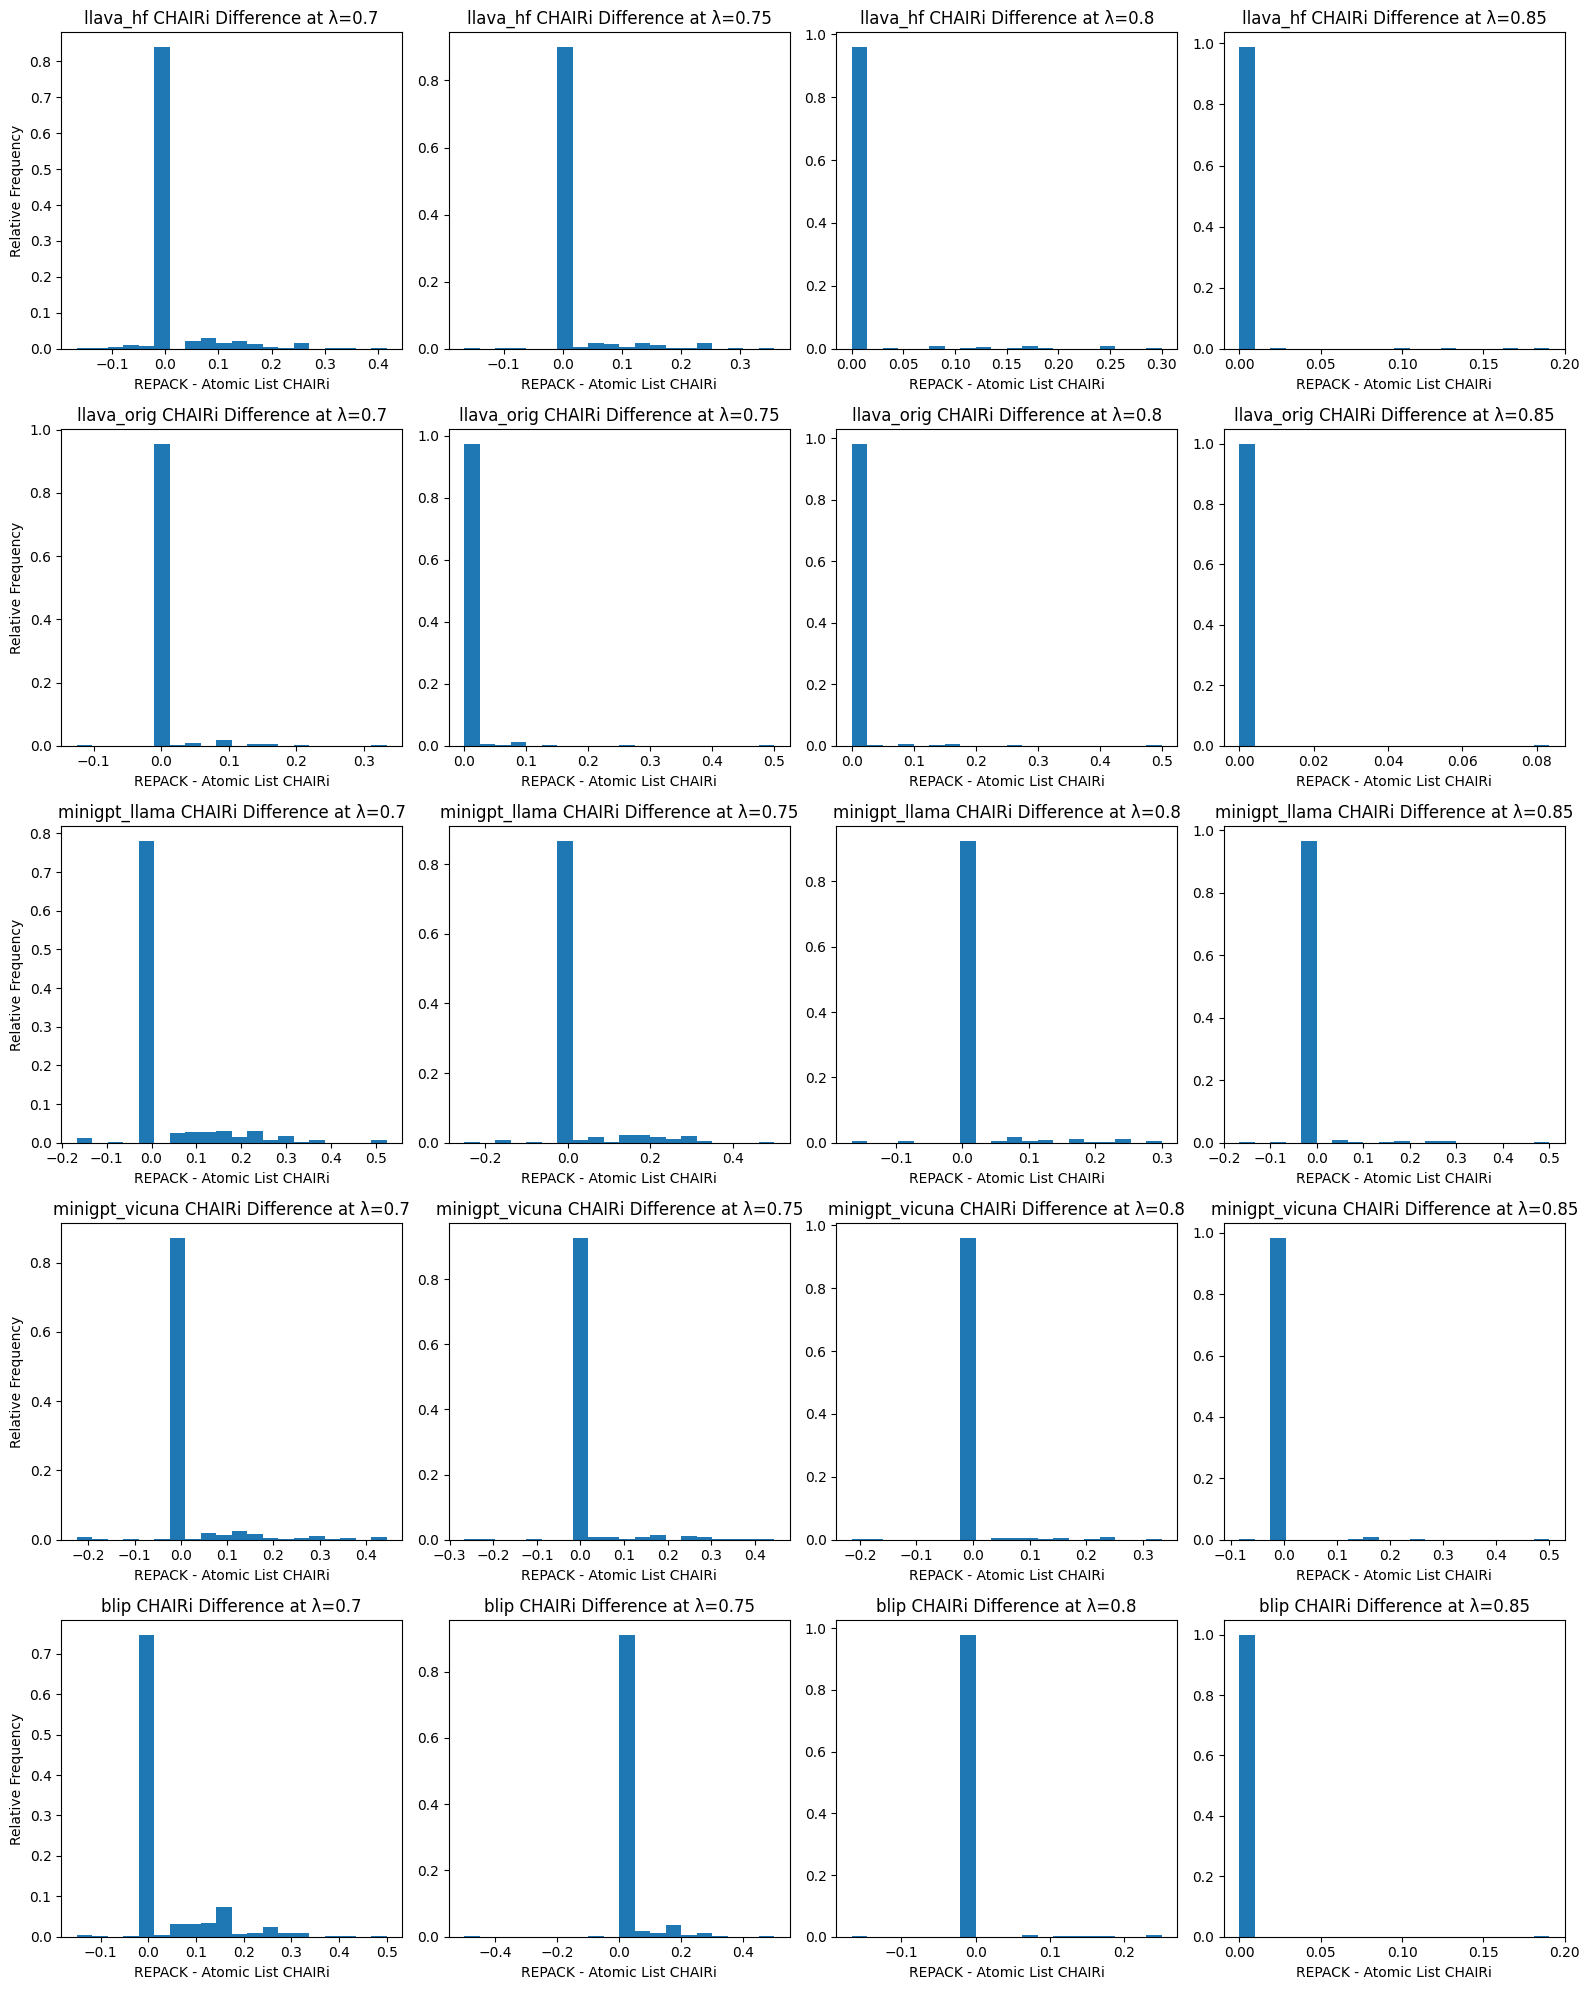

In [30]:
# present results
import matplotlib.pyplot as plt
import numpy as np

thresholds = [0.70, 0.75, 0.80, 0.85]

scale = 4
fig, axes = plt.subplots(
    len(vlms), len(thresholds), figsize=(scale * len(thresholds), scale * len(vlms))
)

for i in range(len(vlms)):
    axes[i][0].set_ylabel("Relative Frequency")

for i, vlm in enumerate(vlms):
    for j, thres in enumerate(thresholds):
        ax = axes[i][j]

        # grab all the data
        chair_before = np.array(atomics_chair[i][j])  # i-th vlm, j-th threshold
        chair_after = np.array(repacked_chair[i][j])

        diffs = chair_after - chair_before  # I sure hope they're the same size
        # plot
        ax.hist(diffs, bins=20, weights=np.ones_like(diffs) / len(diffs))
        ax.set_title(f"{vlm} CHAIRi Difference at λ={thres}")
        ax.set_xlabel(f"REPACK - Atomic List CHAIRi")

fig.tight_layout()
plt.show()

In [17]:
atomics_chair[0]

{'sentences': [{'image_id': 139,
   'caption': 'There is a living room. There is a dining table. There is a couch. There is a woman.',
   'mscoco_hallucinated_words': [('couch', 'couch')],
   'mscoco_gt_words': ['vase',
    'microwave',
    'book',
    'person',
    'clock',
    'chair',
    'refrigerator',
    'tv',
    'dining table',
    'potted plant'],
   'mscoco_generated_words': ['dining table', 'couch', 'person'],
   'hallucination_idxs': [15],
   'recall_gt_objects': ['person', 'dining table'],
   'metrics': {'CHAIRs': 1, 'CHAIRi': 0.3333333333333333, 'Recall': 0.2}},
  {'image_id': 2255,
   'caption': 'There is a large elephant. The elephant is standing. The elephant is on a sandy area.',
   'mscoco_hallucinated_words': [],
   'mscoco_gt_words': ['elephant'],
   'mscoco_generated_words': ['elephant', 'elephant', 'elephant'],
   'hallucination_idxs': [],
   'recall_gt_objects': ['elephant'],
   'metrics': {'CHAIRs': 0, 'CHAIRi': 0.0, 'Recall': 1.0}},
  {'image_id': 2495,
   'c